In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd

In [6]:

FONT_FAMILY = "DejaVu Sans" 
BASE_FONT_SIZE = 10     

mpl.rcParams.update({
    'font.family': FONT_FAMILY,
    'font.size': BASE_FONT_SIZE,            
    'axes.titlesize': BASE_FONT_SIZE + 2,   
    'axes.labelsize': BASE_FONT_SIZE + 0,   
    'xtick.labelsize': BASE_FONT_SIZE - 1,  
    'ytick.labelsize': BASE_FONT_SIZE - 1,  
    'legend.fontsize': BASE_FONT_SIZE - 1,  
    'legend.title_fontsize': BASE_FONT_SIZE,
    'figure.titlesize': BASE_FONT_SIZE + 2, 
    'axes.linewidth': 0.8,             
    'legend.frameon': False,
    'legend.handlelength': 1.2,
    'legend.handleheight': 0.8,
    'savefig.dpi': 300,                    
    'pdf.fonttype': 42,   
    'ps.fonttype': 42,
    'svg.fonttype': 'none'  # 
})

status
Present    1793
Absent      148
Name: count, dtype: int64

 Sample: DRR000713
   Total reads: 11442510
   Fungal reads: 25760.0
   % Fungal reads: 0.23%
   Taxonomy:
kingdom     phylum      subphylum           class           order            family            genus                species  DRR000713
  Fungi Ascomycota Pezizomycotina  Eurotiomycetes      Onygenales Arthrodermataceae     Trichophyton Trichophyton violaceum    21428.0
  Fungi Ascomycota Pezizomycotina   Leotiomycetes    Thelebolales     Thelebolaceae Pseudogymnoascus   Pseudogymnoascus sp.     4023.0
  Fungi Ascomycota Pezizomycotina Sordariomycetes Ophiostomatales  Ophiostomataceae       Ophiostoma      Ophiostoma piceae      309.0

 Sample: ERR11641224
   Total reads: 166748
   Fungal reads: 33.0
   % Fungal reads: 0.02%
   Taxonomy:
kingdom        phylum        subphylum           class             order             family           genus                   species  ERR11641224
  Fungi    Ascomycota   Pezizomycot

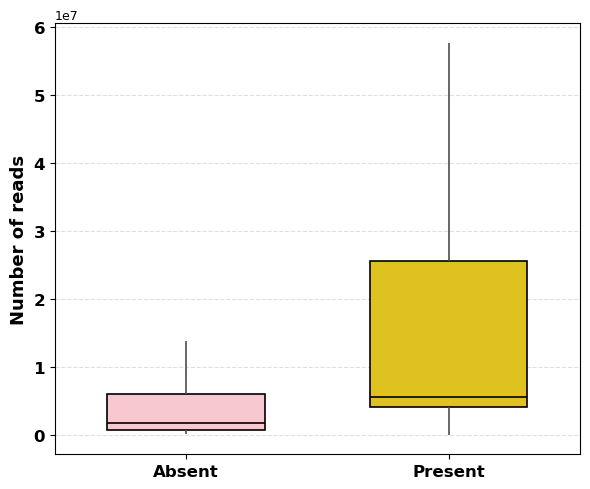

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("kraken_absolute_isyeast_final.tsv", sep="\t", low_memory=False, dtype=str)
df_reads = pd.read_csv("reads_count.tsv", sep="\t")
df_reads.columns = df_reads.columns.str.strip()

meta_file = "cFMD_metadata.tsv"
df_meta = pd.read_csv(meta_file, sep="\t", low_memory=False, dtype=str)

id_columns = ["sample_accession", "run_accession", "experiment_accession",
              "study_accession", "project_accession"]
meta_ids = set(df_meta[id_columns].stack().dropna().unique())

exclude_cols = ['taxid', 'kingdom', 'phylum', 'subphylum', 'class', 'order',
                'family', 'genus', 'species', 'isyeast']
sample_cols = [c for c in df.columns if c not in exclude_cols and c in meta_ids]

for col in sample_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

reads_map = {}
missing_ids = []

for fid in sample_cols:
    match = df_reads.loc[df_reads['taxid'] == fid, 'reads_length']
    if not match.empty:
        reads_map[fid] = match.values[0]
    else:
        reads_map[fid] = 0
        missing_ids.append(fid)

if missing_ids:
    print(missing_ids)

status_map = {}
for fid in sample_cols:
    if ((df[fid] > 0) & (df['isyeast'] == 'Y')).any():
        status_map[fid] = 'Present'
    else:
        status_map[fid] = 'Absent'

data = pd.DataFrame({
    'File_ID': list(reads_map.keys()),
    'reads_length': [reads_map[fid] for fid in reads_map.keys()],
    'status': [status_map[fid] for fid in reads_map.keys()]
})

print(data['status'].value_counts())

absent_samples = data.loc[data['status'] == 'Absent', 'File_ID']
fungal_samples = []
non_fungal_samples = []


for sample in absent_samples:
    sample_reads = reads_map.get(sample, 0)
    fungi_present = df.loc[(df['isyeast'] == 'N') & (df[sample] > 0)]

    if not fungi_present.empty:
        total_fungi_reads = fungi_present[sample].sum()
        print(f"\n Sample: {sample}")
        print(f"   Total reads: {sample_reads}")
        print(f"   Fungal reads: {total_fungi_reads}")
        print(f"   % Fungal reads: {100 * total_fungi_reads / sample_reads:.2f}%")
        print("   Taxonomy:")
        display_cols = ['kingdom', 'phylum', 'subphylum', 'class', 'order',
                        'family', 'genus', 'species', sample]
        print(fungi_present[display_cols].to_string(index=False))
        fungal_samples.append(sample)
    else:
        print(f"\n Sample: {sample}")
        print(f"   Total reads: {sample_reads}")
        non_fungal_samples.append(sample)

if fungal_samples:
    fungal_lengths = [reads_map[s] for s in fungal_samples if reads_map[s] > 0]
    median_fungal = np.median(fungal_lengths)
    print(f"   Samples with fungi without yeasts: {len(fungal_samples)}")
    print(f"   Median reads_length: {median_fungal:.2e}")
else:
    print("   No fungi.")

if non_fungal_samples:
    non_fungal_lengths = [reads_map[s] for s in non_fungal_samples if reads_map[s] > 0]
    median_nonfungal = np.median(non_fungal_lengths)
    print(f"   Samples without any fungi: {len(non_fungal_samples)}")
    print(f"   Median reads_length: {median_nonfungal:.2e}")

    for s in non_fungal_samples:
        mask = df_meta[id_columns].apply(lambda col: col.astype(str) == str(s))
        matched_rows = df_meta.loc[mask.any(axis=1), ['macrocategory', 'category', 'type', 'subtype']].drop_duplicates()

        if not matched_rows.empty:
            print(f"\n Sample: {s}")
            print(matched_rows.to_string(index=False))
        else:
            print(f"\n No match in metadata file for sample: {s}")
else:
    print("  All the samples 'Absent' have fungi.")

filtered_data = data.copy()
filtered_data = filtered_data[
    (filtered_data['status'] == 'Present') |
    ((filtered_data['status'] == 'Absent') & (filtered_data['File_ID'].isin(fungal_samples)))
].reset_index(drop=True)

print(filtered_data['status'].value_counts())

order = ['Absent', 'Present']
palette = {'Absent': 'pink', 'Present': 'gold'}

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data=filtered_data,
    x='status',
    y='reads_length',
    hue='status',
    order=order,
    palette=palette,
    width=0.6,
    linewidth=1.5,
    showfliers=False,
    showcaps=False,
    medianprops={'color': 'black', 'linewidth': 1.2},
    boxprops={'edgecolor': 'black', 'linewidth': 1.2},
    whiskerprops={'linewidth': 1.2},
    legend=False,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Number of reads", fontsize=13, fontweight="bold", fontname="DejaVu Sans")
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("DejaVu Sans")
    label.set_fontsize(12)
    label.set_fontweight("bold")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
#filtered_data.to_csv("Figure5_b2.tsv", sep='\t')

Samples found in metadata: 1941 / 3050


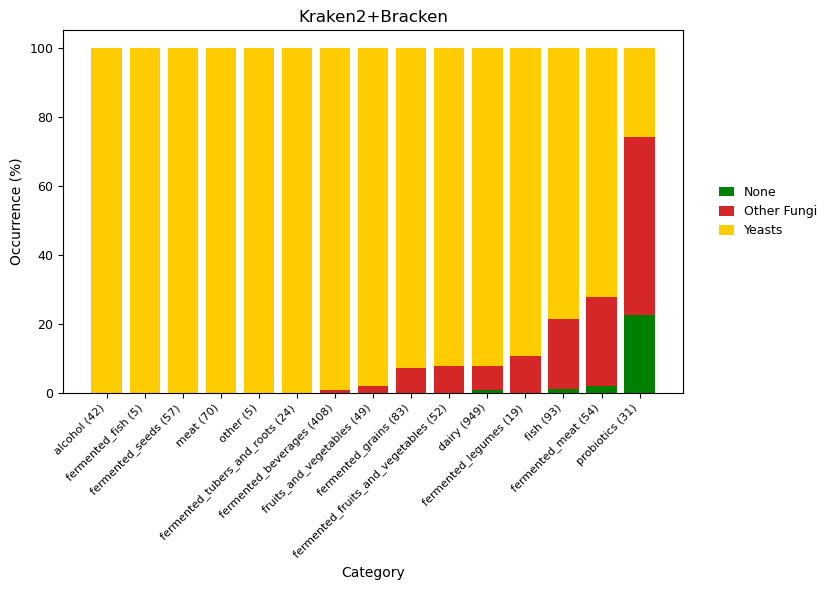

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


counts_file = "kraken_absolute_isyeast_final.tsv"
df_counts = pd.read_csv(counts_file, sep='\t', low_memory=False, dtype=str)

for col in df_counts.columns:
    if col not in ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']:
        df_counts[col] = pd.to_numeric(df_counts[col], errors='coerce').fillna(0)

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
sample_cols = [col for col in df_counts.columns if col not in ignore_cols]

meta_file = "cFMD_metadata.tsv" 
df_meta = pd.read_csv(meta_file, sep='\t', low_memory=False, dtype=str)


id_columns = [
    "sample_accession",
    "run_accession",
    "experiment_accession",
    "study_accession",
    "project_accession"
]


cols_to_keep = id_columns + ["category"]
df_meta = df_meta[cols_to_keep].dropna(subset=["category"])


sample_to_category = {}
warnings = []

for sample in sample_cols:
    matches = []
    for id_col in id_columns:
        if sample in set(df_meta[id_col].dropna()):
            matched_rows = df_meta[df_meta[id_col] == sample]
            categories = matched_rows['category'].unique().tolist()
            for cat in categories:
                matches.append((id_col, cat))
    
    if len(matches) == 1:
        sample_to_category[sample] = matches[0][1]
    elif len(matches) > 1:
        unique_cats = sorted(set([m[1] for m in matches]))
        unique_cols = sorted(set([m[0] for m in matches]))
        warnings.append(f"Sample '{sample}' found in columns {unique_cols} with categories {unique_cats}")
        sample_to_category[sample] = matches[0][1]

if warnings:
    print("\n=== Warning: multiple matches ===")
    for w in warnings:
        print(w)
    print("==========================================\n")

print(f"Samples found in metadata: {len(sample_to_category)} / {len(sample_cols)}")


sample_subcategory = {}
isyeast_vals = df_counts['isyeast']

for sample in sample_cols:
    reads = pd.to_numeric(df_counts[sample], errors='coerce').fillna(0)

    has_yeast = ((isyeast_vals == 'Y') & (reads > 0)).any()
    has_other_fungi = ((isyeast_vals == 'N') & (reads > 0)).any()

    if has_yeast:
        sample_subcategory[sample] = 'Yeast'
    elif has_other_fungi:
        sample_subcategory[sample] = 'Other Fungi'
    else:
        sample_subcategory[sample] = 'None'

categories = sorted(set(sample_to_category.values()))
subcategories = ['None', 'Other Fungi', 'Yeast']

data = {sub: [] for sub in subcategories}
n_samples_per_cat = {}

for cat in categories:
    samples_in_cat = [s for s, c in sample_to_category.items() if c == cat and s in sample_subcategory]
    n_total = len(samples_in_cat)
    n_samples_per_cat[cat] = n_total

    counts = {sub: 0 for sub in subcategories}
    for s in samples_in_cat:
        counts[sample_subcategory[s]] += 1

    for sub in subcategories:
        data[sub].append((counts[sub] / n_total * 100) if n_total > 0 else 0)

df_plot = pd.DataFrame(data, index=categories)

df_plot['n_samples'] = df_plot.index.map(n_samples_per_cat)
df_plot['label'] = [f"{cat} ({n_samples_per_cat[cat]})" for cat in df_plot.index]
df_plot = df_plot.sort_values(by='Yeast', ascending=False)

colors = {
    "None": "green",
    "Other Fungi": "#d62728",
    "Yeast": "#ffcc00"
}

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_plot))
labels = df_plot['label']

none_vals = df_plot['None']
other_vals = df_plot['Other Fungi']
yeast_vals = df_plot['Yeast']

ax.bar(x, none_vals, color=colors["None"], label="None", width=0.8)
ax.bar(x, other_vals, bottom=none_vals, color=colors["Other Fungi"], label="Other Fungi", width=0.8)
ax.bar(x, yeast_vals, bottom=none_vals + other_vals, color=colors["Yeast"], label="Yeasts", width=0.8)

ax.set_title("Kraken2+Bracken", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Occurrence (%)", fontsize=10)
ax.set_xlabel("Category", fontsize=10)
ax.grid(False)

ax.legend(
    bbox_to_anchor=(1.05, 0.5),
    loc="center left",
    borderaxespad=0.0,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
#df_plot.to_csv("Figure5_a2.tsv", sep='\t')


/tmp/ipykernel_5491/2512167078.py:36: UserWarning: Sample 'SRR13308535' has 2 matches in the metadata file.
  warnings.warn(f"Sample '{sample}' has {len(matches)} matches in the metadata file.")
/tmp/ipykernel_5491/2512167078.py:36: UserWarning: Sample 'SRR27278107' has 2 matches in the metadata file.
  warnings.warn(f"Sample '{sample}' has {len(matches)} matches in the metadata file.")
/tmp/ipykernel_5491/2512167078.py:36: UserWarning: Sample 'SRR27278118' has 2 matches in the metadata file.
  warnings.warn(f"Sample '{sample}' has {len(matches)} matches in the metadata file.")
/tmp/ipykernel_5491/2512167078.py:36: UserWarning: Sample 'SRR27278121' has 2 matches in the metadata file.
  warnings.warn(f"Sample '{sample}' has {len(matches)} matches in the metadata file.")
/tmp/ipykernel_5491/2512167078.py:36: UserWarning: Sample 'SRR27278122' has 2 matches in the metadata file.
  warnings.warn(f"Sample '{sample}' has {len(matches)} matches in the metadata file.")
/tmp/ipykernel_5491/25121

Samples with assigned category: 1941/3050
Subphyla trovati (inclusi None e Non Yeast): ['Agaricomycotina', 'Entomophthoromycotina', 'Glomeromycotina', 'Kickxellomycotina', 'Mortierellomycotina', 'Mucoromycotina', 'None', 'Pezizomycotina', 'Pucciniomycotina', 'Saccharomycotina', 'Taphrinomycotina', 'Ustilaginomycotina', 'Wallemiomycotina', 'Zoopagomycotina']


/tmp/ipykernel_5491/2512167078.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_counts['subphylum_norm'] = df_counts['subphylum'].replace('', 'None').str.capitalize()


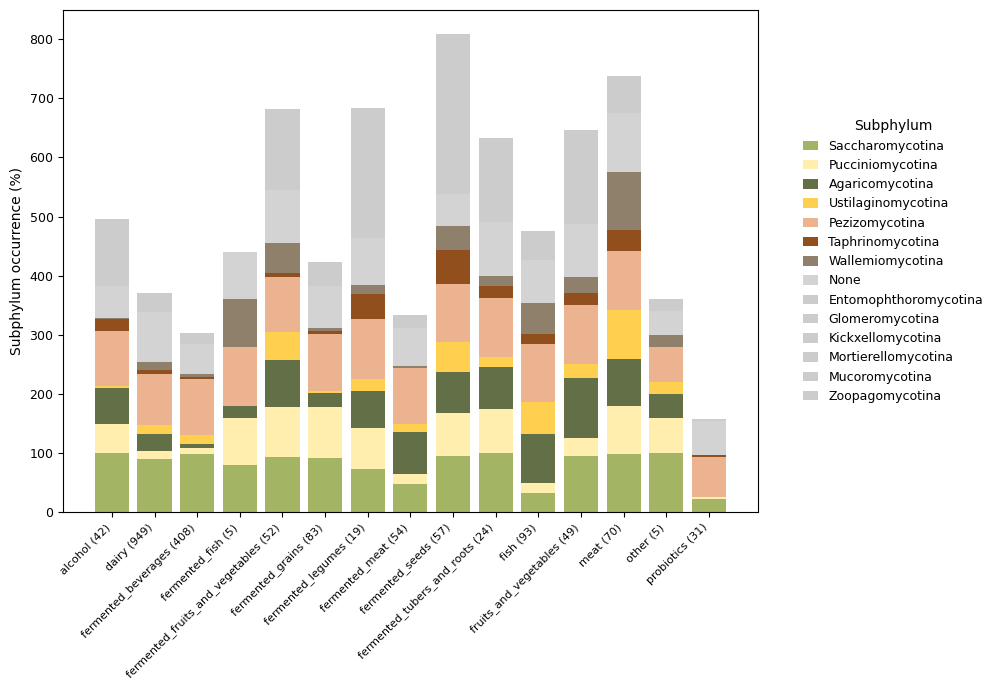

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from matplotlib.font_manager import FontProperties

counts_file = "kraken_absolute_isyeast_final.tsv"
df_counts = pd.read_csv(counts_file, sep='\t', low_memory=False, dtype=str)

for col in df_counts.columns:
    if col not in ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']:
        df_counts[col] = pd.to_numeric(df_counts[col], errors='coerce').fillna(0)

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
sample_cols = [c for c in df_counts.columns if c not in ignore_cols]

meta_file = "cFMD_metadata.tsv"
df_meta = pd.read_csv(meta_file, sep='\t', low_memory=False, dtype=str)

id_columns = [
    "sample_accession",
    "run_accession",
    "experiment_accession",
    "study_accession",
    "project_accession"
]

sample_to_category = {}
multiple_matches = []

for sample in sample_cols:
    matches = df_meta[df_meta[id_columns].isin([sample]).any(axis=1)]
    if len(matches) == 1:
        sample_to_category[sample] = matches.iloc[0]['category']
    elif len(matches) > 1:
        warnings.warn(f"Sample '{sample}' has {len(matches)} matches in the metadata file.")
        multiple_matches.append(sample)
        sample_to_category[sample] = matches.iloc[0]['category']
    else:
        sample_to_category[sample] = None

n_matched = sum(v is not None for v in sample_to_category.values())
print(f"Samples with assigned category: {n_matched}/{len(sample_cols)}")

df_samples = pd.DataFrame.from_dict(sample_to_category, orient='index', columns=['category']).dropna()
categories = sorted(df_samples['category'].unique())

df_counts['subphylum'] = df_counts['subphylum'].fillna('').str.strip()
df_counts['subphylum_norm'] = df_counts['subphylum'].replace('', 'None').str.capitalize()

subphyla = sorted(df_counts['subphylum_norm'].unique())
print(f"Subphyla trovati (inclusi None e Non Yeast): {subphyla}")


data = {sp: [] for sp in subphyla}
n_samples_per_cat = {}

for cat in categories:
    samples_in_cat = df_samples[df_samples['category'] == cat].index
    n_total = len(samples_in_cat)
    n_samples_per_cat[cat] = n_total

    for sp in subphyla:
        subset = df_counts[df_counts['subphylum_norm'] == sp]
        if subset.empty:
            frac = 0
        else:
            positive_samples = (subset[samples_in_cat] > 0).any(axis=0)
            n_positive = positive_samples.sum()
            frac = (n_positive / n_total * 100) if n_total > 0 else 0
        data[sp].append(frac)

df_plot = pd.DataFrame(data, index=categories)


custom_colors = {
    'Saccharomycotina': "#A4B465",
    'Pucciniomycotina': "#FFEEAD",
    'Agaricomycotina': "#626F47",
    'Ustilaginomycotina': "#FFCF50",
    'Pezizomycotina': "#ECB390",
    'Taphrinomycotina': "#914F1E",
    'Non Yeast': "#6A7FDB",
    'Wallemiomycotina': "#8E806A",
    'None': "#D3D3D3"
}

for sp in subphyla:
    if sp not in custom_colors:
        custom_colors[sp] = "#CCCCCC"


df_plot['n_samples'] = df_plot.index.map(n_samples_per_cat)
df_plot['label'] = [f"{cat} ({n_samples_per_cat[cat]})" for cat in df_plot.index]

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(df_plot))

subphyla_ordered = [sp for sp in custom_colors.keys() if sp in df_plot.columns]
bottom = np.zeros(len(df_plot))

for sp in subphyla_ordered:
    vals = df_plot[sp] if sp in df_plot.columns else np.zeros(len(df_plot))
    ax.bar(x, vals, bottom=bottom, label=sp, color=custom_colors[sp], width=0.8)
    bottom += vals 

ax.set_xticks(x)
ax.set_xticklabels(df_plot['label'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Subphylum occurrence (%)", fontsize=10)
ax.grid(False)

handles, labels = ax.get_legend_handles_labels()
handles_filtered, labels_filtered = [], []

for h, l in zip(handles, labels):
    if l in custom_colors:
        handles_filtered.append(h)
        labels_filtered.append(l)

BASE_FONT_SIZE = 10
legend = ax.legend(
    handles_filtered,
    labels_filtered,
    bbox_to_anchor=(1.05, 0.5),
    loc="center left",
    frameon=False,
    title="Subphylum"
)
legend.set_title("Subphylum", prop=FontProperties(size=BASE_FONT_SIZE))
for text in legend.get_texts():
    text.set_fontsize(BASE_FONT_SIZE - 1)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

#df_plot.to_csv("Figure6_food_subphyla_occurrences_fungi.tsv", sep='\t')

                  DRR000713  DRR000714   DRR205701   DRR205702   DRR205703  \
subphylum                                                                    
Agaricomycotina         0.0     1885.0     13942.0     22268.0     66340.0   
Pezizomycotina          0.0        0.0       121.0       570.0       847.0   
Pucciniomycotina        0.0        0.0         0.0         0.0         0.0   
Saccharomycotina        0.0        0.0  24122248.0  13155132.0  58937344.0   
Taphrinomycotina        0.0        0.0         0.0         0.0         0.0   

                  ERR11641224  ERR11641227  ERR11641277  ERR11641279  \
subphylum                                                              
Agaricomycotina           0.0          0.0          0.0          0.0   
Pezizomycotina            0.0          0.0          0.0          0.0   
Pucciniomycotina          0.0          0.0          0.0          0.0   
Saccharomycotina          0.0          0.0          0.0          0.0   
Taphrinomycotina     

/tmp/ipykernel_5491/1292064272.py:43: UserWarning: Sample ERR2226381 ha total_reads=0, salto.
  warnings.warn(f"Sample {sample} ha total_reads=0, salto.")
/tmp/ipykernel_5491/1292064272.py:43: UserWarning: Sample ERR2226382 ha total_reads=0, salto.
  warnings.warn(f"Sample {sample} ha total_reads=0, salto.")
/tmp/ipykernel_5491/1292064272.py:43: UserWarning: Sample ERR2226383 ha total_reads=0, salto.
  warnings.warn(f"Sample {sample} ha total_reads=0, salto.")
/tmp/ipykernel_5491/1292064272.py:43: UserWarning: Sample ERR2226384 ha total_reads=0, salto.
  warnings.warn(f"Sample {sample} ha total_reads=0, salto.")
/tmp/ipykernel_5491/1292064272.py:43: UserWarning: Sample ERR2226385 ha total_reads=0, salto.
  warnings.warn(f"Sample {sample} ha total_reads=0, salto.")
/tmp/ipykernel_5491/1292064272.py:43: UserWarning: Sample ERR2226386 ha total_reads=0, salto.
  warnings.warn(f"Sample {sample} ha total_reads=0, salto.")
/tmp/ipykernel_5491/1292064272.py:43: UserWarning: Sample SRR1745841 h

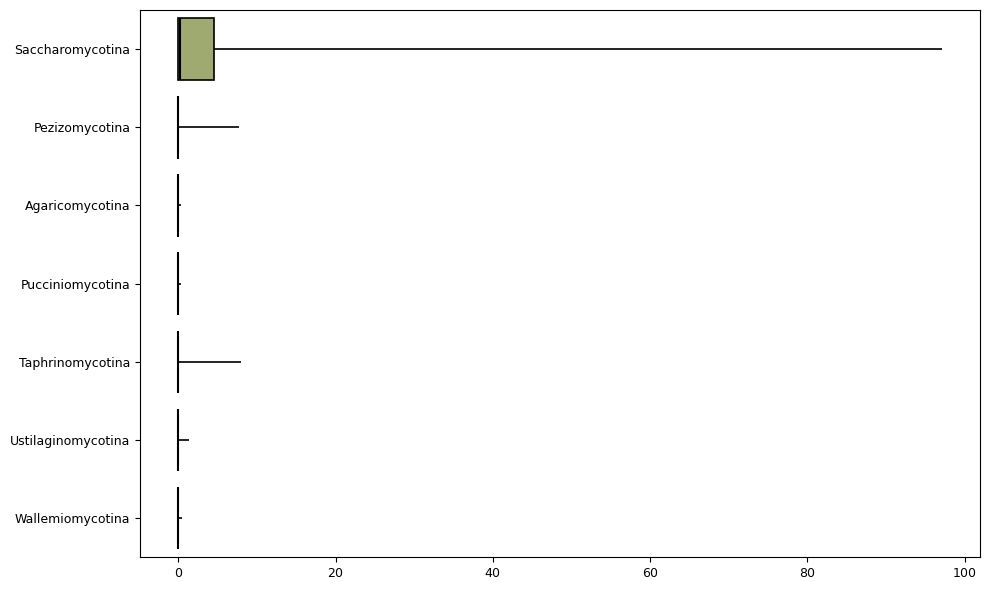

         Subphylum     Q1  Median     Q3     Max  Avg_total_reads_within_subphylum  Avg_reads_for_detected_samples  N_detected_samples
   Agaricomycotina 0.0000  0.0000 0.0000  0.3975                               NaN                             NaN                 195
    Pezizomycotina 0.0000  0.0000 0.0000  7.7781                               NaN                             NaN                 351
  Pucciniomycotina 0.0000  0.0000 0.0000  0.3574                               NaN                             NaN                  62
  Saccharomycotina 0.0251  0.2734 4.5657 97.0959                               NaN                             NaN                1706
  Taphrinomycotina 0.0000  0.0000 0.0000  8.0059                               NaN                             NaN                 194
Ustilaginomycotina 0.0000  0.0000 0.0000  1.3637                               NaN                             NaN                 365
  Wallemiomycotina 0.0000  0.0000 0.0000  0.4288       

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


df_counts = pd.read_csv("kraken_absolute_isyeast_final.tsv", sep="\t", low_memory=False, dtype=str)
df_reads = pd.read_csv("reads_food_microbiomes_k2_B.tsv", sep="\t")
df_meta = pd.read_csv("cFMD_metadata.tsv", sep="\t")

tax_cols = ['taxid', 'kingdom', 'phylum', 'subphylum', 'class', 'order', 'family',
            'genus', 'species', 'isyeast']

meta_cols = ["sample_accession", "run_accession", "experiment_accession", "study_accession", "project_accession"]
meta_ids = set(df_meta[meta_cols].values.flatten())

sample_cols = [c for c in df_counts.columns if c not in tax_cols and c in meta_ids]

filtered_df = df_counts[df_counts["isyeast"] == "Y"][tax_cols + sample_cols].copy()

for c in sample_cols:
    filtered_df[c] = pd.to_numeric(filtered_df[c], errors='coerce').fillna(0)


agg_df = filtered_df.groupby("subphylum")[sample_cols].sum()
print(agg_df.head())

df_reads["total"] = pd.to_numeric(df_reads["total"], errors='coerce')

rel_abundances = []
valid_samples = []
total_reads_dict = {}

for sample in sample_cols:
    match = df_reads[df_reads["taxid"] == sample]
    if match.empty:
        warnings.warn(f"Sample {sample} non trovato in df_reads, salto.")
        continue

    total_reads = match["total"].values[0]
    total_reads_dict[sample] = total_reads
    if total_reads == 0:
        warnings.warn(f"Sample {sample} ha total_reads=0, salto.")
        continue

    rel_abundances.append((agg_df[sample] / total_reads) * 100)
    valid_samples.append(sample)

rel_df = pd.concat(rel_abundances, axis=1)
rel_df.columns = valid_samples

rel_melted = rel_df.T.melt(var_name="Subphylum", value_name="Relative_Abundance")
rel_melted["Sample"] = rel_melted.index
rel_melted["Total_Reads"] = rel_melted["Sample"].map(total_reads_dict)
rel_melted["Reads_Subphylum"] = rel_melted["Relative_Abundance"] * rel_melted["Total_Reads"] / 100

order = (
    rel_melted.groupby("Subphylum")["Relative_Abundance"]
    .quantile(0.75)
    .sort_values(ascending=False)
    .index
)

custom_colors = {
    'Saccharomycotina': "#A4B465",
    'Pucciniomycotina': "#FFEEAD",
    'Agaricomycotina': "#626F47",
    'Ustilaginomycotina': "#FFCF50",
    'Pezizomycotina': "#ECB390",
    'Taphrinomycotina': "#914F1E",
    'Entomophthoromycotina': "#D5CEA3",
    'Glomeromycotina': "#C2B280",
    'Mortierellomycotina': "#B7A57A",
    'Mucoromycotina': "#A67B5B",
    'Wallemiomycotina': "#8E806A",
    'Zoopagomycotina': "#C0A080",
    'Kickxellomycotina': "#B08B4F",
    'Olpidiomycotina' : "#839788",
    'None': "#D3D3D3"
}

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=rel_melted,
    y="Subphylum",
    x="Relative_Abundance",
    order=order,
    palette=custom_colors,
    hue="Subphylum",
    legend=False,
    linewidth=0.8,
    fliersize=0,
    whis=[0, 100],
    dodge=False,
    whiskerprops={'color': 'black', 'linewidth': 1.2},
    capprops={'color': 'black', 'linewidth': 0},
    boxprops={'edgecolor': 'black', 'linewidth': 1.2},
    medianprops={'color': 'black', 'linewidth': 1.5}
)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

summary = []
for subphylum, group in rel_melted.groupby("Subphylum"):
    if group["Relative_Abundance"].sum() == 0:
        continue
    q1 = group["Relative_Abundance"].quantile(0.25)
    median = group["Relative_Abundance"].quantile(0.5)
    q3 = group["Relative_Abundance"].quantile(0.75)
    vmax = group["Relative_Abundance"].max()
    avg_total_reads = group["Total_Reads"].mean()
    avg_reads_sub = group["Reads_Subphylum"].mean()
    n_detected_samples = group[group["Relative_Abundance"] > 0]["Sample"].nunique()

    summary.append({
        "Subphylum": subphylum,
        "Q1": q1,
        "Median": median,
        "Q3": q3,
        "Max": vmax,
        "Avg_total_reads_within_subphylum": avg_total_reads,
        "Avg_reads_for_detected_samples": avg_reads_sub,
        "N_detected_samples": n_detected_samples
    })

df_summary = pd.DataFrame(summary)
df_summary = df_summary.round({
    "Q1": 4, "Median": 4, "Q3": 4, "Max": 4,
    "Avg_total_reads_within_subphylum": 2,
    "Avg_reads_for_detected_samples": 2
})

print(df_summary.to_string(index=False))
#rel_melted.to_csv("Figure7_2.tsv", sep='\t')

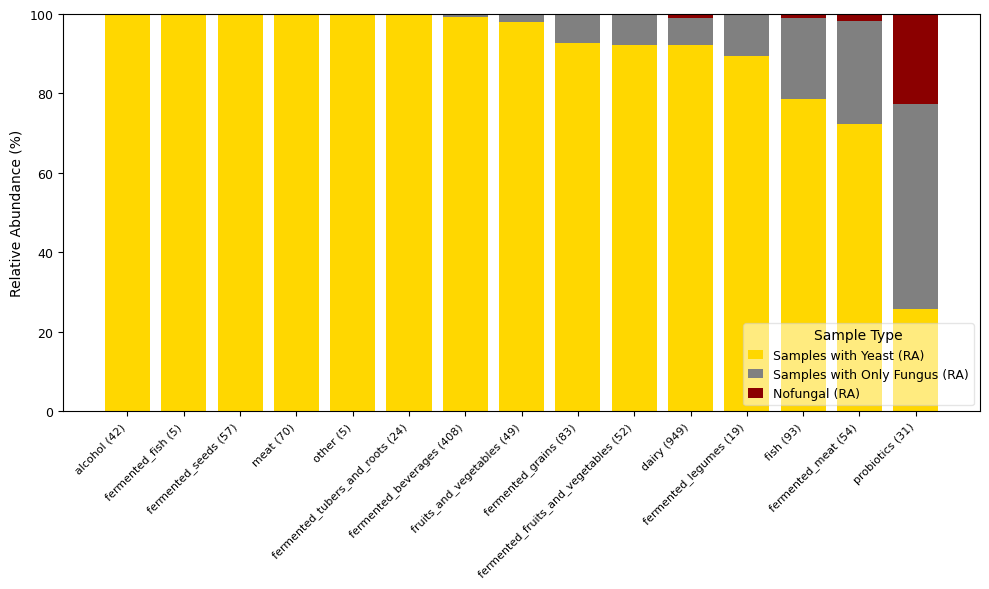

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


counts_file = "kraken_absolute_isyeast_final.tsv"
meta_file = "cFMD_metadata.tsv"

df_counts = pd.read_csv(counts_file, sep='\t', low_memory=False, dtype=str)

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
sample_cols = [col for col in df_counts.columns if col not in ignore_cols]

for col in sample_cols:
    df_counts[col] = pd.to_numeric(df_counts[col], errors='coerce').fillna(0)


df_meta = pd.read_csv(meta_file, sep='\t', low_memory=False, dtype=str)

id_columns = [
    "sample_accession", "run_accession", "experiment_accession", 
    "study_accession", "project_accession"
]
cols_to_keep = id_columns + ["category"]
df_meta = df_meta[cols_to_keep].dropna(subset=["category"])

sample_to_category = {}
for sample in sample_cols:
    matches = []
    for id_col in id_columns:
        if sample in set(df_meta[id_col].dropna()):
            matched_rows = df_meta[df_meta[id_col] == sample]
            categories = matched_rows['category'].unique().tolist()
            for cat in categories:
                matches.append(cat)
    
    if matches:
        sample_to_category[sample] = matches[0] # Prendi il primo match

sample_subcategory = {}
isyeast_vals = df_counts['isyeast']

for sample in sample_cols:
    reads = df_counts[sample] # Già convertito in numerico all'inizio!

    has_yeast = ((isyeast_vals == 'Y') & (reads > 0)).any()
    has_other_fungi = ((isyeast_vals == 'N') & (reads > 0)).any()

    if has_yeast:
        sample_subcategory[sample] = 'Yeast'
    elif has_other_fungi:
        sample_subcategory[sample] = 'Other Fungi'
    else:
        sample_subcategory[sample] = 'None'

categories = sorted(set(sample_to_category.values()))
subcategories = ['None', 'Other Fungi', 'Yeast']

data = {sub: [] for sub in subcategories}
n_samples_per_cat = {}

for cat in categories:
    samples_in_cat = [s for s, c in sample_to_category.items() if c == cat and s in sample_subcategory]
    n_total = len(samples_in_cat)
    n_samples_per_cat[cat] = n_total

    counts = {sub: 0 for sub in subcategories}
    for s in samples_in_cat:
        counts[sample_subcategory[s]] += 1

    for sub in subcategories:
        data[sub].append((counts[sub] / n_total * 100) if n_total > 0 else 0)

df_plot = pd.DataFrame(data, index=categories)
df_plot['n_samples'] = df_plot.index.map(n_samples_per_cat)
df_plot['label'] = [f"{cat} ({n_samples_per_cat[cat]})" for cat in df_plot.index]
df_plot = df_plot.sort_values(by='Yeast', ascending=False)

#output_tsv = "food/food_fungi_distribution_K2_B.tsv"
#df_plot.to_csv(output_tsv, sep='\t')


df_plot = df_plot.rename(columns={
    "Yeast": "Samples with Yeast (RA)",
    "Other Fungi": "Samples with Only Fungus (RA)",
    "None": "Nofungal (RA)"
})

category_order = df_plot['label'].tolist()
df_plot = df_plot.set_index('label').reindex(category_order)

columns_to_plot = ['Samples with Yeast (RA)',
                   'Samples with Only Fungus (RA)',
                   'Nofungal (RA)']
colors = ['gold', 'gray', 'darkred']

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(df_plot))

for col, color in zip(columns_to_plot, colors):
    values = df_plot[col].values
    ax.bar(df_plot.index, values, bottom=bottom, color=color, width=0.8, label=col)
    bottom += values

ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Relative Abundance (%)", fontsize=10) # Ho aggiunto (%) per chiarezza
ax.set_xlabel("")  
ax.grid(False, axis='y')

ax.legend(
    title='Sample Type',
    loc='lower right',
    frameon=True,
    facecolor='white',
    framealpha=0.5,
    title_fontsize=10,
    fontsize=9
)

plt.tight_layout()
plt.show()
#df_plot.to_csv("plots/figure12/Figure12_f.tsv", sep='\t')

Sample 'SRR13308535' found in 2 matches. Category selected 'dairy' (frequency 2)
Sample 'SRR27278107' found in 2 matches. Category selected 'meat' (frequency 2)
Sample 'SRR27278118' found in 2 matches. Category selected 'meat' (frequency 2)
Sample 'SRR27278121' found in 2 matches. Category selected 'meat' (frequency 2)
Sample 'SRR27278122' found in 2 matches. Category selected 'meat' (frequency 2)
Sample 'SRR27278123' found in 2 matches. Category selected 'meat' (frequency 2)
Sample 'SRR27278124' found in 2 matches. Category selected 'meat' (frequency 2)
Sample 'SRR27278125' found in 2 matches. Category selected 'meat' (frequency 2)
Sample 'SRR27278126' found in 2 matches. Category selected 'meat' (frequency 2)
Sample 'SRR27278127' found in 2 matches. Category selected 'meat' (frequency 2)
Sample 'SRR27278128' found in 2 matches. Category selected 'meat' (frequency 2)
Sample 'SRR27278129' found in 2 matches. Category selected 'meat' (frequency 2)
Sample 'SRR27278130' found in 2 matches

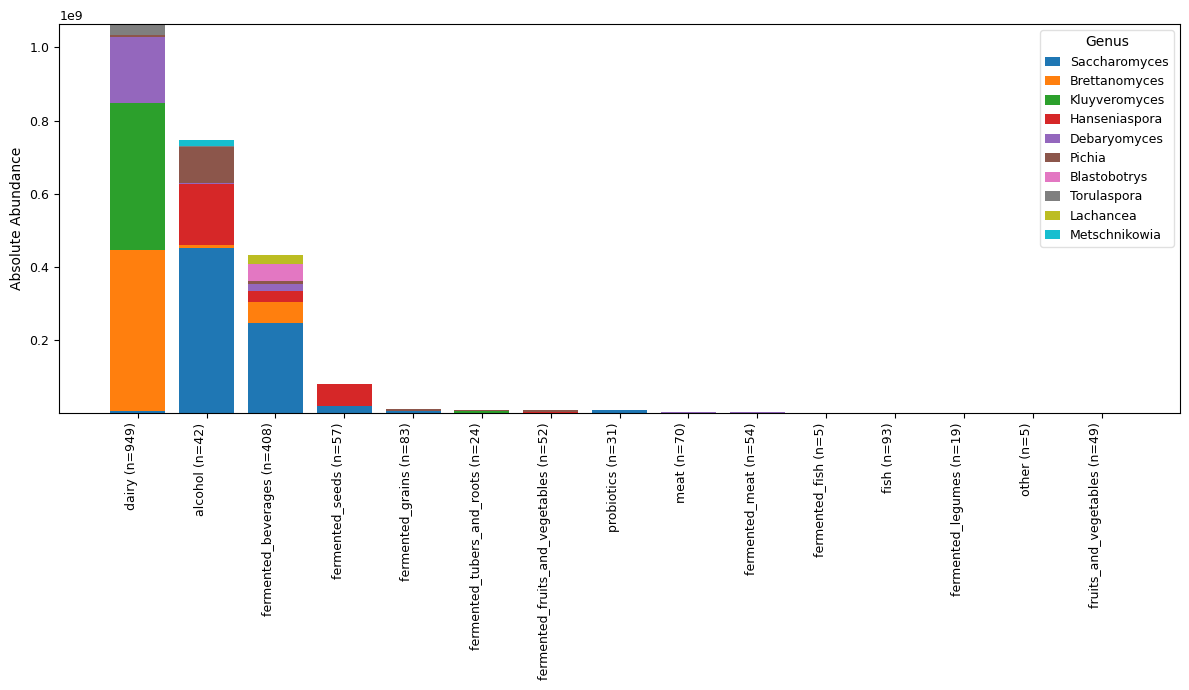

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

counts_file = "kraken_absolute_isyeast_final.tsv"
df_counts = pd.read_csv(counts_file, sep='\t', low_memory=False, dtype=str)

for col in df_counts.columns:
    if col not in ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']:
        df_counts[col] = pd.to_numeric(df_counts[col], errors='coerce').fillna(0)

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
sample_cols = [col for col in df_counts.columns if col not in ignore_cols]

meta_file = "cFMD_metadata.tsv"
df_meta = pd.read_csv(meta_file, sep='\t', low_memory=False, dtype=str)

id_columns = [
    "sample_accession",
    "run_accession",
    "experiment_accession",
    "study_accession",
    "project_accession"
]

cols_to_keep = id_columns + ["macrocategory", "category", "type", "subtype"]
df_meta = df_meta[cols_to_keep].dropna(subset=["category"])

sample_to_category = {}
warnings = []

for sample in sample_cols:
    matches = []
    for id_col in id_columns:
        matched_rows = df_meta[df_meta[id_col] == sample]
        if not matched_rows.empty:
            for _, row in matched_rows.iterrows():
                matches.append(row["category"])
    
    if len(matches) == 1:
        sample_to_category[sample] = matches[0]
    elif len(matches) > 1:
        freq = Counter(matches)
        most_common_cat, count = freq.most_common(1)[0]
        warnings.append(
            f"Sample '{sample}' found in {len(matches)} matches. Category selected '{most_common_cat}' (frequency {count})"
        )
        sample_to_category[sample] = most_common_cat

if warnings:
    for w in warnings:
        print(w)
    print("==========================================\n")

df_yeast = df_counts[df_counts['isyeast'] == 'Y']
genus_sums = df_yeast.groupby("genus")[sample_cols].sum()
genus_total = genus_sums.sum(axis=1).sort_values(ascending=False)
top10_genus = genus_total.head(10).index.tolist()

category_abundance = {genus: {} for genus in top10_genus}
samples_per_category = {}

for sample, cat in sample_to_category.items():
    if sample not in genus_sums.columns:
        continue
    samples_per_category[cat] = samples_per_category.get(cat, 0) + 1
    for genus in top10_genus:
        reads = genus_sums.at[genus, sample]
        category_abundance[genus][cat] = category_abundance[genus].get(cat, 0) + reads

df_abundance = pd.DataFrame(category_abundance).fillna(0)
df_abundance['n_samples'] = [samples_per_category.get(cat,0) for cat in df_abundance.index]
df_abundance['total_abundance'] = df_abundance[top10_genus].sum(axis=1)
df_abundance = df_abundance.sort_values(by='total_abundance', ascending=False)
df_abundance = df_abundance.drop(columns='total_abundance')

#df_abundance.to_csv("Figure12_g.tsv", sep='\t')

plt.figure(figsize=(12, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(top10_genus)))
genus_color_map = dict(zip(top10_genus, colors))

bottom = np.zeros(len(df_abundance))

for genus in top10_genus:
    vals = df_abundance[genus].values
    plt.bar(df_abundance.index, vals, bottom=bottom, label=genus,
            color=genus_color_map[genus])
    bottom += vals

labels = [f"{cat} (n={df_abundance.loc[cat,'n_samples']})" for cat in df_abundance.index]

plt.ylabel("Absolute Abundance")
plt.xlabel("")
plt.xticks(range(len(df_abundance.index)), labels, rotation=90, ha='right')

plt.legend(
    title="Genus",
    loc="upper right",
    frameon=True,
    facecolor='white',
    framealpha=0.6,
    fontsize=9
)

plt.tight_layout()
plt.show()

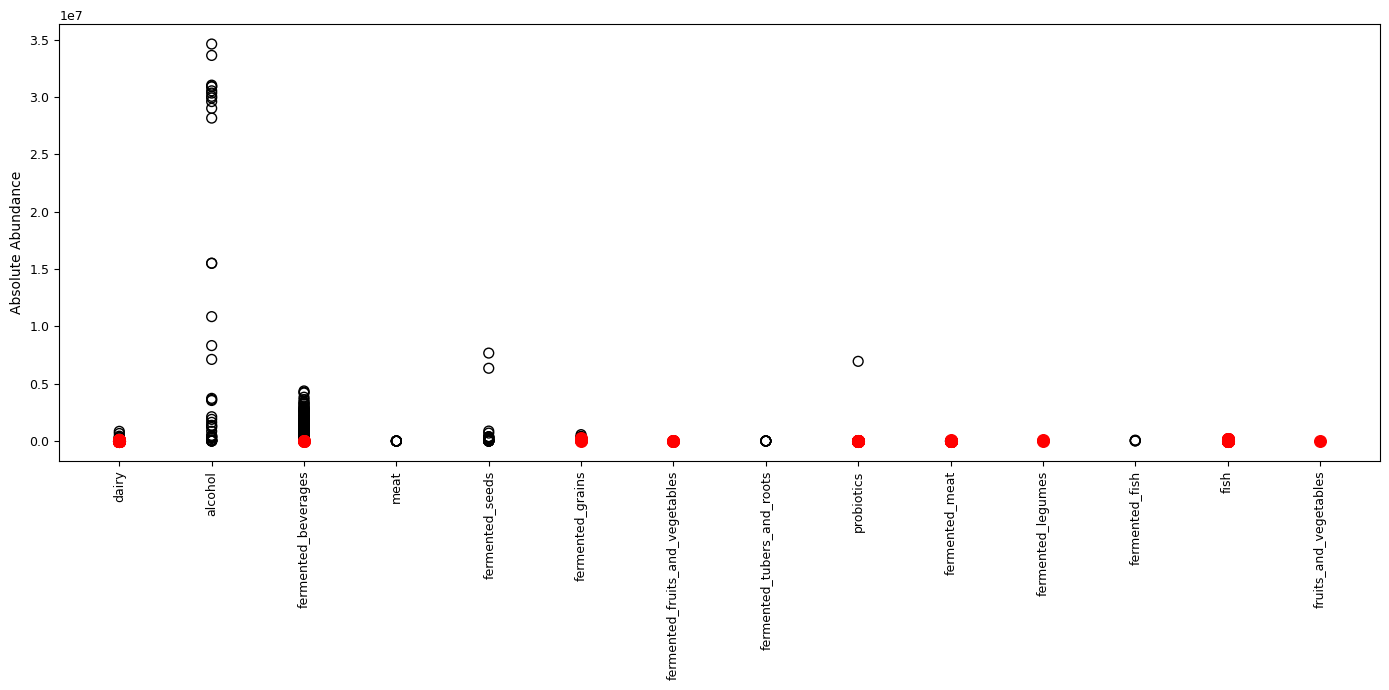

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

counts_file = "kraken_absolute_isyeast_final.tsv"
df_counts = pd.read_csv(counts_file, sep='\t', low_memory=False, dtype=str)

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
sample_cols = [col for col in df_counts.columns if col not in ignore_cols]

for col in sample_cols:
    df_counts[col] = pd.to_numeric(df_counts[col], errors='coerce').fillna(0)

meta_file = "cFMD_metadata.tsv"
df_meta = pd.read_csv(meta_file, sep='\t', low_memory=False, dtype=str)

id_columns = ["sample_accession","run_accession","experiment_accession","study_accession","project_accession"]
cols_to_keep = id_columns + ["macrocategory","category","type","subtype"]
df_meta = df_meta[cols_to_keep].dropna(subset=["category"])

sample_metadata = {}
for sample in sample_cols:
    for id_col in id_columns:
        matched_rows = df_meta[df_meta[id_col] == sample]
        if not matched_rows.empty:
            row = matched_rows.iloc[0]
            sample_metadata[sample] = {
                'category': row.get('category', 'other'),
                'sample_accession': row.get('sample_accession', ''),
                'run_accession': row.get('run_accession', ''),
                'experiment_accession': row.get('experiment_accession', ''),
                'study_accession': row.get('study_accession', ''),
                'project_accession': row.get('project_accession', ''),
                'macrocategory': row.get('macrocategory', ''),
                'type': row.get('type', ''),
                'subtype': row.get('subtype', '')
            }
            break  

genus_col = df_counts['genus'].fillna('')
df_saccharomyces = df_counts[genus_col.str.lower() == 'saccharomyces'].copy()

isyeast_col = df_counts['isyeast'].fillna('')
df_yeast = df_counts[isyeast_col == 'Y'].copy()       
df_non_yeast = df_counts[isyeast_col == 'N'].copy()   

saccharo_rows = []

for sample in sample_cols:
    if sample not in sample_metadata:
        continue
    
    if sample in df_saccharomyces.columns:
        abundance = df_saccharomyces[sample].sum()
        if abundance > 0:
            row_data = {'sample': sample, 'abundance': abundance}
            row_data.update(sample_metadata[sample])  
            saccharo_rows.append(row_data)

scatter_saccharo_df = pd.DataFrame(saccharo_rows)

non_yeast_samples = []

for sample in sample_cols:
    if sample not in sample_metadata:
        continue
    
    sample_yeast_abundance = df_yeast[sample].sum() if sample in df_yeast.columns else 0
    if sample_yeast_abundance == 0:
        abundance = df_non_yeast[sample].sum() if sample in df_non_yeast.columns else 0
        if abundance > 0:
            row_data = {'sample': sample, 'abundance': abundance}
            row_data.update(sample_metadata[sample])
            non_yeast_samples.append(row_data)

scatter_non_yeast_df = pd.DataFrame(non_yeast_samples)

category_order = [
    'dairy', 'alcohol', 'fermented_beverages', 'meat', 
    'fermented_seeds', 'fermented_grains', 'fermented_fruits_and_vegetables',
    'fermented_tubers_and_roots', 'probiotics', 'fermented_meat',
    'fish', 'fruits_and_vegetables', 'fermented_legumes', 'fermented_fish', 'other'
]

if not scatter_saccharo_df.empty:
    scatter_saccharo_df['category'] = pd.Categorical(scatter_saccharo_df['category'], categories=category_order, ordered=True)
if not scatter_non_yeast_df.empty:
    scatter_non_yeast_df['category'] = pd.Categorical(scatter_non_yeast_df['category'], categories=category_order, ordered=True)

plt.figure(figsize=(14,7))

if not scatter_saccharo_df.empty:
    for cat in category_order:
        df_cat = scatter_saccharo_df[scatter_saccharo_df['category']==cat]
        if not df_cat.empty:
            plt.scatter([cat]*len(df_cat), df_cat['abundance'], facecolors='none', edgecolors='black', s=50, label='Saccharomyces' if cat == category_order[0] else "")


if not scatter_non_yeast_df.empty:
    for cat in category_order:
        df_cat = scatter_non_yeast_df[scatter_non_yeast_df['category']==cat]
        if not df_cat.empty:
            plt.scatter([cat]*len(df_cat), df_cat['abundance'], color='red', s=70, label='Non-yeast' if cat == category_order[0] else "")

plt.xticks(rotation=90)
plt.ylabel("Absolute Abundance")
plt.xlabel("")
plt.tight_layout()
plt.show()

taxonomy_cols = ['kingdom','phylum','subphylum','class','order','family','genus','species']

def get_taxonomy_for_sample(df_from_taxa, sample_name, df_counts_full, taxonomy_cols):
    if sample_name not in df_from_taxa.columns:
        return {c: None for c in taxonomy_cols}
    try:
        idx_max = df_from_taxa[sample_name].astype(float).idxmax()
    except Exception:
        return {c: None for c in taxonomy_cols}

    df_counts_unique = df_counts_full.loc[:, ~df_counts_full.columns.duplicated()]
    if idx_max in df_counts_unique.index:
        row = df_counts_unique.loc[idx_max]
    else:
        return {c: None for c in taxonomy_cols}
        
    out = {}
    for c in taxonomy_cols:
        out[c] = row[c] if c in row.index else None
    return out

if not scatter_saccharo_df.empty:
    top3_saccharo = []
    for cat in category_order:
        df_cat = scatter_saccharo_df[scatter_saccharo_df['category'] == cat]
        if not df_cat.empty:
            top3_saccharo.append(df_cat.nlargest(3, 'abundance'))
            
    if top3_saccharo:
        top3_saccharo_df = pd.concat(top3_saccharo, axis=0).reset_index(drop=True)
        tax_rows = [get_taxonomy_for_sample(df_saccharomyces, row['sample'], df_counts, taxonomy_cols) for _, row in top3_saccharo_df.iterrows()]
        top3_saccharo_final = pd.concat([pd.DataFrame(tax_rows), top3_saccharo_df], axis=1)
        #top3_saccharo_final.to_csv("top3_saccharomyces_per_category_food.tsv", sep='\t', index=False)
    
    #scatter_saccharo_df.to_csv("Figure12_h_black_dots.tsv", sep='\t', index=False)

if not scatter_non_yeast_df.empty:
    top3_non_yeast = []
    for cat in category_order:
        df_cat = scatter_non_yeast_df[scatter_non_yeast_df['category'] == cat]
        if not df_cat.empty:
            top3_non_yeast.append(df_cat.nlargest(3, 'abundance'))
            
    if top3_non_yeast:
        top3_non_yeast_df = pd.concat(top3_non_yeast, axis=0).reset_index(drop=True)
        tax_rows = [get_taxonomy_for_sample(df_non_yeast, row['sample'], df_counts, taxonomy_cols) for _, row in top3_non_yeast_df.iterrows()]
        top3_non_yeast_final = pd.concat([pd.DataFrame(tax_rows), top3_non_yeast_df], axis=1)
        #top3_non_yeast_final.to_csv("top3_non_yeast_per_category_food.tsv", sep='\t', index=False)
        
    #scatter_non_yeast_df.to_csv("Figure12_h_red_dots.tsv", sep='\t', index=False)


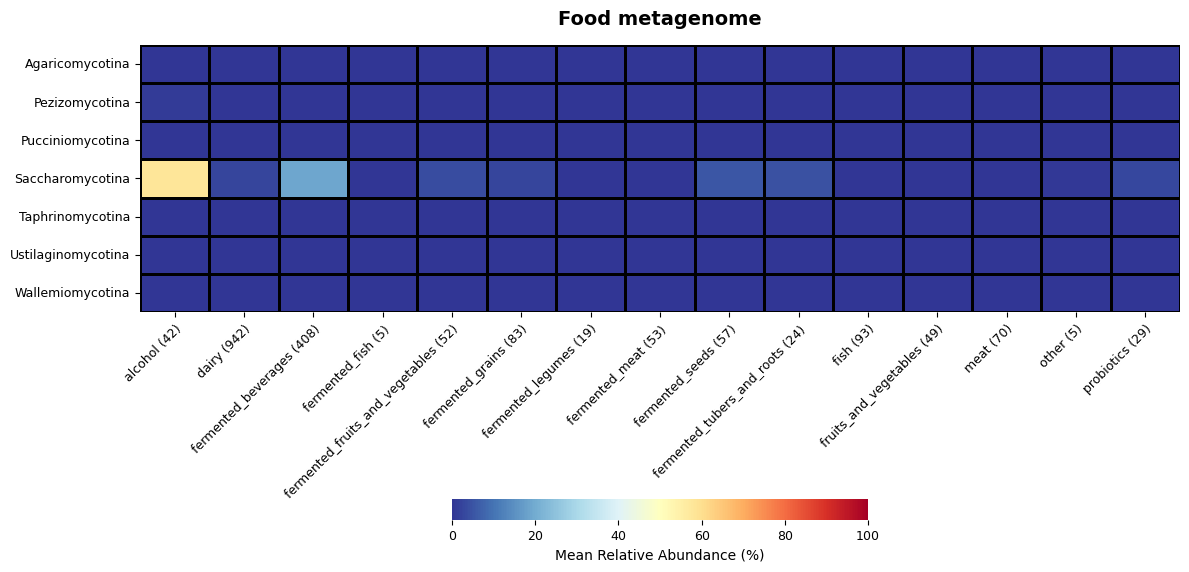

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

df_counts = pd.read_csv("kraken_absolute_isyeast_final.tsv", sep="\t", low_memory=False, dtype=str)
df_reads = pd.read_csv("reads_food_microbiomes_k2_B.tsv", sep="\t")
df_meta = pd.read_csv("cFMD_metadata.tsv", sep="\t")

meta_map = df_meta.set_index('run_accession')['category'].dropna().to_dict()


df_reads["total"] = pd.to_numeric(df_reads["total"], errors='coerce')
reads_dict = df_reads.set_index('taxid')['total'].to_dict()


sample_cols = [c for c in df_counts.columns if c in meta_map and c in reads_dict and reads_dict[c] > 0]

yeast_df = df_counts[df_counts['isyeast'] == 'Y'].copy()

for c in sample_cols:
    yeast_df[c] = pd.to_numeric(yeast_df[c], errors='coerce').fillna(0)

yeast_grouped = yeast_df.groupby('subphylum')[sample_cols].sum()

rel_abund_df = yeast_grouped.copy()
for sample in sample_cols:
    rel_abund_df[sample] = (rel_abund_df[sample] / reads_dict[sample]) * 100

df_melted = rel_abund_df.T.reset_index()
df_melted.rename(columns={'index': 'sample_name'}, inplace=True)

df_melted['category'] = df_melted['sample_name'].map(meta_map)

mean_abund = df_melted.groupby('category').mean(numeric_only=True).T

sample_counts = df_melted['category'].value_counts().to_dict()

mean_abund.columns = [f"{col} ({sample_counts[col]})" for col in mean_abund.columns]

mean_abund = mean_abund.sort_index()

plt.figure(figsize=(12, 6))

ax = sns.heatmap(
    mean_abund,
    vmin=0,
    vmax=100,
    cmap="RdYlBu_r",         
    linewidths=1, 
    linecolor='black', 
    cbar_kws={'label': 'Mean Relative Abundance (%)', 'orientation': 'horizontal', 'shrink': 0.4, 'pad': 0.35}
)

plt.title("Food metagenome", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("")
plt.ylabel("")

plt.xticks(rotation=45, ha='right', rotation_mode="anchor")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


#mean_abund.to_csv("Heatmap_Food_data_mean_relative_abundances.tsv", sep='\t')

In [15]:
import pandas as pd
import numpy as np
from collections import Counter


counts_file = "kraken_absolute_isyeast_final.tsv"
df_counts = pd.read_csv(counts_file, sep='\t', low_memory=False, dtype=str)

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
initial_sample_cols = [col for col in df_counts.columns if col not in ignore_cols]

meta_file = "cFMD_metadata.tsv"
df_meta = pd.read_csv(meta_file, sep='\t', low_memory=False, dtype=str)

id_columns = ["sample_accession", "run_accession", "experiment_accession", "study_accession", "project_accession"]
df_meta = df_meta.dropna(subset=["category"])

valid_metadata_ids = set()
for col in id_columns:
    valid_metadata_ids.update(df_meta[col].dropna().tolist())

valid_sample_cols = [sample for sample in initial_sample_cols if sample in valid_metadata_ids]
total_valid_samples = len(valid_sample_cols)

for col in valid_sample_cols:
    df_counts[col] = pd.to_numeric(df_counts[col], errors='coerce').fillna(0)

df_counts['isyeast'] = df_counts['isyeast'].str.strip().str.upper()

df_yeast = df_counts[df_counts['isyeast'] == 'Y']
df_non_yeast = df_counts[df_counts['isyeast'] == 'N']

yeast_sample_totals = df_yeast[valid_sample_cols].sum(axis=0)
non_yeast_sample_totals = df_non_yeast[valid_sample_cols].sum(axis=0)
all_fungi_sample_totals = df_counts[valid_sample_cols].sum(axis=0)

yeast_count = (yeast_sample_totals > 0).sum()
non_yeast_count = (non_yeast_sample_totals > 0).sum()
zero_fungi_count = (all_fungi_sample_totals == 0).sum()

perc_yeast = (yeast_count / total_valid_samples) * 100
perc_non_yeast = (non_yeast_count / total_valid_samples) * 100
perc_zero = (zero_fungi_count / total_valid_samples) * 100

print("\n" + "="*60)
print("Results")
print("="*60)
print(f"🔹 Samples with at least one yeast (Y):      {yeast_count} su {total_valid_samples} ({perc_yeast:.2f}%)")
print(f"🔹 Samples with at least one non-yeast (N):  {non_yeast_count} su {total_valid_samples} ({perc_non_yeast:.2f}%)")
print(f"🔹 Samples without fungi:   {zero_fungi_count} su {total_valid_samples} ({perc_zero:.2f}%)")
print("="*60)

both_count = ((yeast_sample_totals > 0) & (non_yeast_sample_totals > 0)).sum()
perc_both = (both_count / total_valid_samples) * 100
print(f"Note: Samples with both yeast and non-yeast fungi: {both_count} ({perc_both:.2f}%)")


Results
🔹 Samples with at least one yeast (Y):      1793 su 1941 (92.38%)
🔹 Samples with at least one non-yeast (N):  1892 su 1941 (97.48%)
🔹 Samples without fungi:   18 su 1941 (0.93%)
Note: Samples with both yeast and non-yeast fungi: 1762 (90.78%)
